In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

In [12]:
file = pd.read_csv("../final4.csv")

In [13]:
file.head()

,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,cf_cvg,NDVI_raw,...,SSSMASS,TOTEXTTAU,TOTSCATAU,temp_mean,temp_max,temp_min,rainfall,wind_mean,humid_mean,shortwave_radiation
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.855020,2021-01-06,0.66,5.0,3792.0,...,3.725563e-08,0.175115,0.165737,26.58,28.52,24.74,15.17,1.31,85.53,17.65
1,1,Columba livia,Colombo,31.0,6.927894,79.865005,2024-09-24,25.40,1.0,5692.0,...,5.924096e-08,0.191869,0.184795,27.52,29.55,26.03,2.63,5.50,84.41,20.77
2,2,Hirundo rustica,Colombo,10.0,6.866285,79.931440,2024-12-23,10.16,7.0,7045.0,...,3.249729e-08,0.198127,0.187366,26.21,28.84,24.10,0.25,2.51,84.30,20.49
3,3,Geokichla spiloptera,Matale,1.0,7.401229,80.690730,2024-09-13,1.13,1.0,9506.0,...,3.795434e-08,0.162928,0.156176,27.29,32.96,23.45,0.17,4.11,76.89,22.42
4,4,Himantopus himantopus,Puttalam,6.0,8.154166,79.736084,2024-11-28,0.79,2.0,NaN,...,4.148581e-08,0.213164,0.203239,25.86,27.55,24.85,0.99,6.15,84.07,8.78


In [22]:
selected_features = ['index', 'decimalLatitude', 'decimalLongitude', 'eventDate','temp_mean', 'temp_max', 'temp_min',
                     'rainfall', 'wind_mean', 'humid_mean', 'shortwave_radiation']


df_selected = file[selected_features]

In [23]:
df_selected.head()

,index,decimalLatitude,decimalLongitude,eventDate,temp_mean,temp_max,temp_min,rainfall,wind_mean,humid_mean,shortwave_radiation
0,0,9.058512,79.855020,2021-01-06,26.58,28.52,24.74,15.17,1.31,85.53,17.65
1,1,6.927894,79.865005,2024-09-24,27.52,29.55,26.03,2.63,5.50,84.41,20.77
2,2,6.866285,79.931440,2024-12-23,26.21,28.84,24.10,0.25,2.51,84.30,20.49
3,3,7.401229,80.690730,2024-09-13,27.29,32.96,23.45,0.17,4.11,76.89,22.42
4,4,8.154166,79.736084,2024-11-28,25.86,27.55,24.85,0.99,6.15,84.07,8.78


In [21]:
df_selected.columns

Index(['index', 'decimalLatitude', 'decimalLongitude', 'temp_mean', 'temp_max',
       'temp_min', 'rainfall', 'wind_mean', 'humid_mean',
       'shortwave_radiation'],
      dtype='str')

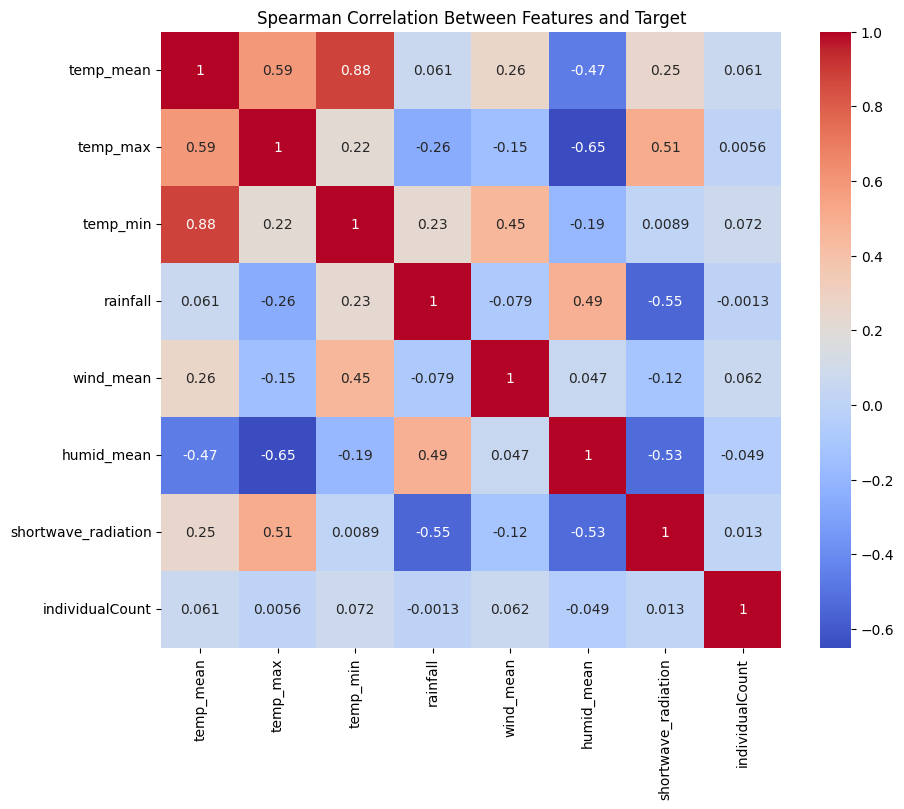

Correlation of each feature with target:
temp_mean: Spearman corr = 0.061, p-value = 0
temp_max: Spearman corr = 0.006, p-value = 1.45e-15
temp_min: Spearman corr = 0.072, p-value = 0
rainfall: Spearman corr = -0.001, p-value = 0.0688
wind_mean: Spearman corr = 0.062, p-value = 0
humid_mean: Spearman corr = -0.049, p-value = 0
shortwave_radiation: Spearman corr = 0.013, p-value = 3.81e-78


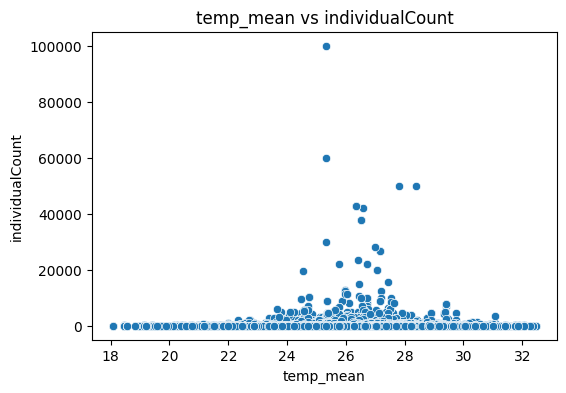

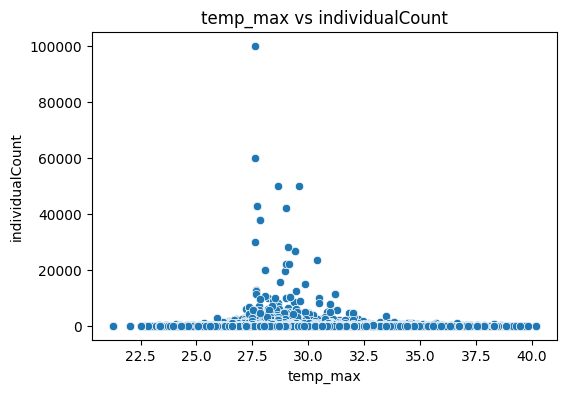

KeyboardInterrupt: 

In [32]:
features = ['temp_mean', 'temp_max', 'temp_min', 'rainfall', 'wind_mean', 'humid_mean', 'shortwave_radiation']
target = 'individualCount'  # replace with your bird metric

# --- 1. Correlation matrix ---
corr_matrix = file[features + [target]].corr(method='spearman')  # Spearman is better for non-linear monotonic relationships
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Between Features and Target")
plt.show()

# --- 2. Individual correlation with target ---
print("Correlation of each feature with target:")
for f in features:
    corr, p_val = spearmanr(file[f], file[target])
    print(f"{f}: Spearman corr = {corr:.3f}, p-value = {p_val:.3g}")

# --- 3. Scatterplots to visualize relationships ---
for f in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=file[f], y=file[target])
    plt.title(f"{f} vs {target}")
    plt.xlabel(f)
    plt.ylabel(target)
    plt.show()